# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [7]:
import pandas as pd
import numpy as np
from utils import (
    sigmoid, make_sigmoid_basis, fit_ridge_closed_form, predict, metrics,
    mse, fit_ridge, add_bias, poly_features, rbf_features, sigmoid_stable,
    sigmoid_features, spline_features, make_design_matrix, select_feature_groups,
    interaction_terms
)
import matplotlib.pyplot as plt

## **2. Load Data for Model**

In [8]:

energy_path = "../../data/raw/Energy_Use.csv"
df_energy = pd.read_csv(energy_path)
if 'date' in df_energy.columns:
    df_energy['date'] = pd.to_datetime(df_energy['date'], format='%d-%m-%Y %H:%M', errors='ignore')


C:\Users\Admin\AppData\Local\Temp\ipykernel_14584\2949817478.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df_energy['date'] = pd.to_datetime(df_energy['date'], format='%d-%m-%Y %H:%M', errors='ignore')


In [9]:

# --- 9.2 Time-series split (no shuffle) ---
# Target: Appliances
# Features: all numeric except target; drop raw datetime column

df_model = df_energy.copy()
if 'date' in df_model.columns:
    df_model = df_model.sort_values('date').reset_index(drop=True)

if 'Appliances' not in df_model.columns:
    raise ValueError("Column 'Appliances' not found in df_energy")

y = df_model['Appliances'].to_numpy(dtype=float)

X_df = df_model.drop(columns=['Appliances'], errors='ignore')
X_df = X_df.drop(columns=['date'], errors='ignore')

# Keep only numeric columns
X_df = X_df.select_dtypes(include=[np.number]).copy()
feature_names = list(X_df.columns)
X = X_df.to_numpy(dtype=float)

n = X.shape[0]
train_end = int(0.70 * n)
val_end = int(0.80 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Shapes:")
print("- X_train:", X_train.shape, "y_train:", y_train.shape)
print("- X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("- X_test :", X_test.shape, "y_test :", y_test.shape)

# --- 9.3 Feature scaling (fit on train only) ---
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
# avoid divide-by-zero
sigma = np.where(sigma == 0, 1.0, sigma)

X_train_s = (X_train - mu) / sigma
X_val_s = (X_val - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("\nScaling check (train):")
print("- mean (first 5 dims):", X_train_s.mean(axis=0)[:5])
print("- std  (first 5 dims):", X_train_s.std(axis=0)[:5])

# keep for later cells
splits = {
    'X_train_s': X_train_s,
    'y_train': y_train,
    'X_val_s': X_val_s,
    'y_val': y_val,
    'X_test_s': X_test_s,
    'y_test': y_test,
    'feature_names': feature_names,
}



Shapes:
- X_train: (13814, 27) y_train: (13814,)
- X_val  : (1974, 27) y_val  : (1974,)
- X_test : (3947, 27) y_test : (3947,)

Scaling check (train):
- mean (first 5 dims): [-1.64596551e-17 -6.58386204e-16 -4.93789653e-16  2.91335895e-15
  7.40684479e-17]
- std  (first 5 dims): [1. 1. 1. 1. 1.]


## **3. Model Implementation & Baseline Evaluation**
### **3.1 Task 1: Sigmoid Basis Baseline**


Design matrix shapes:
- Phi_train: (13814, 163)
- Phi_val  : (1974, 163)
- Phi_test : (3947, 163)

Metrics (Sigmoid basis + Ridge closed-form)
- Train: {'RMSE': 93.49458810018244, 'MAE': 53.67323748825623, 'R2': 0.23441034188072274}
- Val  : {'RMSE': 90.04307148408033, 'MAE': 58.45857852931051, 'R2': 0.05431563482329349}
- Test : {'RMSE': 152.10455942533474, 'MAE': 101.88246697186598, 'R2': -1.7914766020428385}


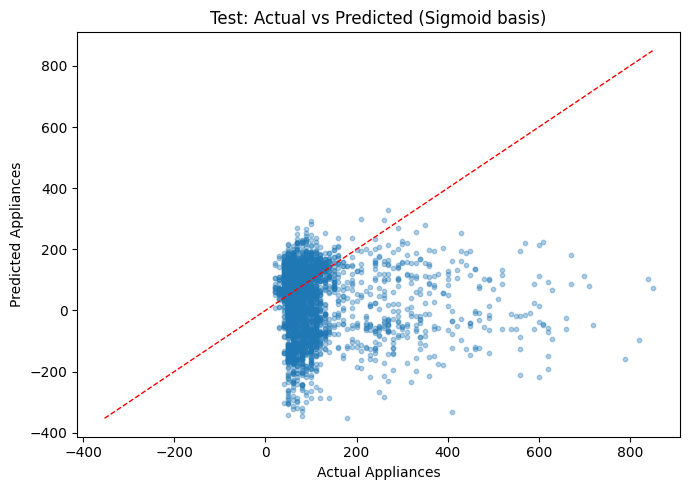

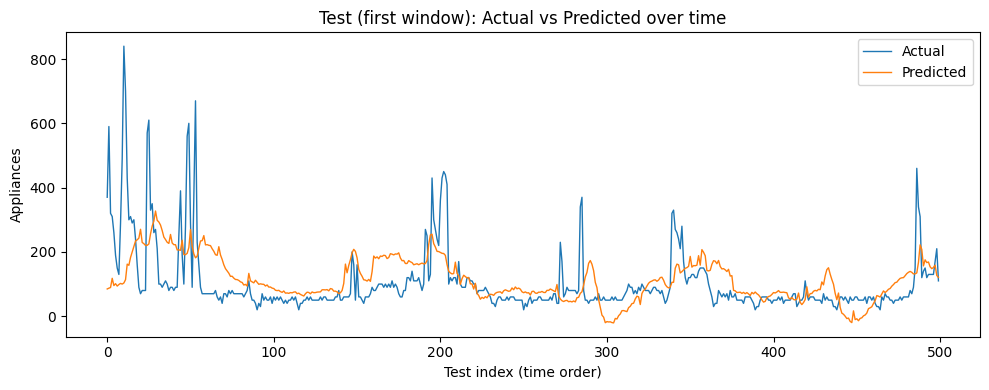

In [10]:
# --- Task 1: Sigmoid basis (chosen) + linear regression (ridge, closed-form) ---











X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']

N_tr, D = X_train_s.shape

# Hyperparams (can tune later)
M = 5           # number of sigmoid bases per feature
slope = 2.0     # sigmoid steepness in scaled space
lam = 1.0       # ridge strength

# Choose centers from train distribution (quantiles in scaled space)
# centers[d, m] = quantile of feature d at q_m
qs = np.linspace(0.1, 0.9, M)
centers = np.zeros((D, M), dtype=float)
for d in range(D):
    centers[d] = np.quantile(X_train_s[:, d], qs)

Phi_train = make_sigmoid_basis(X_train_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_val = make_sigmoid_basis(X_val_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_test = make_sigmoid_basis(X_test_s, centers=centers, slope=slope, include_linear=True, include_bias=True)

print("Design matrix shapes:")
print("- Phi_train:", Phi_train.shape)
print("- Phi_val  :", Phi_val.shape)
print("- Phi_test :", Phi_test.shape)

w = fit_ridge_closed_form(Phi_train, y_train, lam=lam, bias_is_first=True)

pred_train = predict(Phi_train, w)
pred_val = predict(Phi_val, w)
pred_test = predict(Phi_test, w)

m_train = metrics(y_train, pred_train)
m_val = metrics(y_val, pred_val)
m_test = metrics(y_test, pred_test)

print("\nMetrics (Sigmoid basis + Ridge closed-form)")
print("- Train:", m_train)
print("- Val  :", m_val)
print("- Test :", m_test)

# Quick plot: actual vs predicted (test)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_test, s=10, alpha=0.35)
mn = min(y_test.min(), pred_test.min())
mx = max(y_test.max(), pred_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
plt.xlabel('Actual Appliances')
plt.ylabel('Predicted Appliances')
plt.title('Test: Actual vs Predicted (Sigmoid basis)')
plt.tight_layout()
plt.show()

# Also plot first 500 timesteps of test (time order)
plt.figure(figsize=(10, 4))
idx = np.arange(len(y_test))
cut = min(500, len(y_test))
plt.plot(idx[:cut], y_test[:cut], label='Actual', linewidth=1)
plt.plot(idx[:cut], pred_test[:cut], label='Predicted', linewidth=1)
plt.title('Test (first window): Actual vs Predicted over time')
plt.xlabel('Test index (time order)')
plt.ylabel('Appliances')
plt.legend()
plt.tight_layout()
plt.show()


## **4. Four Basis Functions & Validation Curves**
### **4.1 Validation Curves: MSE vs. Hyperparameters**


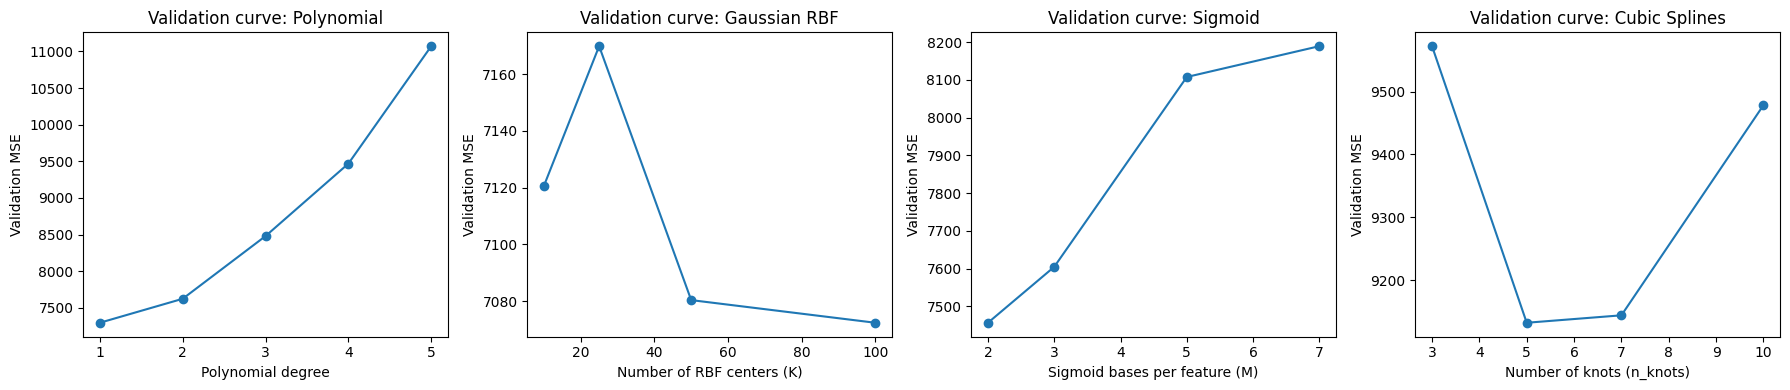

Validation MSE summary:
- Polynomial: {1: 7295.828122052771, 2: 7623.169828872532, 3: 8479.523765885664, 4: 9468.597782241824, 5: 11072.558785958028}
- RBF       : {10: 7120.648137147934, 25: 7169.879495850643, 50: 7080.398354382025, 100: 7072.41849660271}
- Sigmoid   : {2: 7456.310530823122, 3: 7604.591204524112, 5: 8107.754722287199, 7: 8189.464670470794}
- Splines   : {3: 9572.33736567915, 5: 9132.291922796967, 7: 9144.1184804012, 10: 9478.387732678259}


In [11]:
# --- Task 1 (continued): Polynomial + Gaussian RBF + Sigmoid + Cubic Splines, validation curves, ablation, interactions ---

X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']





# ------------------------
# Validation curves (MSE)
# ------------------------
lam = 1.0
rng = np.random.default_rng(0)

# Polynomial: vary degree
poly_degrees = [1, 2, 3, 4, 5]
poly_val_mse = []
for d in poly_degrees:
    basis = {'poly_degree': d, 'rbf': None, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    poly_val_mse.append(mse(y_val, Phi_va @ w))

# RBF: vary number of centers K
rbf_Ks = [10, 25, 50, 100]
rbf_val_mse = []
for K in rbf_Ks:
    # deterministic subset of train as centers
    take = min(K, X_train_s.shape[0])
    idx_c = rng.choice(X_train_s.shape[0], size=take, replace=False)
    centers = X_train_s[idx_c]

    # gamma from median distance between centers (heuristic)
    # avoid O(K^2) when K large by subsampling
    cc = centers
    if cc.shape[0] >= 2:
        sample = cc[rng.choice(cc.shape[0], size=min(200, cc.shape[0]), replace=False)]
        d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
        med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    else:
        med = 1.0
    gamma = 1.0 / (2.0 * med)

    basis = {'poly_degree': None, 'rbf': {'centers': centers, 'gamma': gamma}, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    rbf_val_mse.append(mse(y_val, Phi_va @ w))

# Sigmoid: vary M (number of sigmoids per feature)
sig_Ms = [2, 3, 5, 7]
sig_val_mse = []
for M in sig_Ms:
    qs = np.linspace(0.1, 0.9, M)
    D = X_train_s.shape[1]
    centers_pf = np.zeros((D, M), dtype=float)
    for d in range(D):
        centers_pf[d] = np.quantile(X_train_s[:, d], qs)
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': centers_pf, 'slope': 2.0}, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    sig_val_mse.append(mse(y_val, Phi_va @ w))

# Splines (Cubic): vary n_knots
spline_knots = [3, 5, 7, 10]
spline_val_mse = []
for k in spline_knots:
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': k, 'degree': 3}}
    # IMPORTANT: fit spline transformer on train once, then reuse for val
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    spline_val_mse.append(mse(y_val, Phi_va @ w))

plt.figure(figsize=(18, 4))
plt.subplot(1, 4, 1)
plt.plot(poly_degrees, poly_val_mse, marker='o')
plt.xlabel('Polynomial degree')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Polynomial')

plt.subplot(1, 4, 2)
plt.plot(rbf_Ks, rbf_val_mse, marker='o')
plt.xlabel('Number of RBF centers (K)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Gaussian RBF')

plt.subplot(1, 4, 3)
plt.plot(sig_Ms, sig_val_mse, marker='o')
plt.xlabel('Sigmoid bases per feature (M)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Sigmoid')

plt.subplot(1, 4, 4)
plt.plot(spline_knots, spline_val_mse, marker='o')
plt.xlabel('Number of knots (n_knots)')
plt.ylabel('Validation MSE')
plt.title('Validation curve: Cubic Splines')

plt.tight_layout()
plt.show()

print('Validation MSE summary:')
print('- Polynomial:', dict(zip(poly_degrees, poly_val_mse)))
print('- RBF       :', dict(zip(rbf_Ks, rbf_val_mse)))
print('- Sigmoid   :', dict(zip(sig_Ms, sig_val_mse)))
print('- Splines   :', dict(zip(spline_knots, spline_val_mse)))


# ------------------------
# Ablation study


## **5. Ablation Studies**
### **5.1 Basis Function Ablation**


In [12]:
# 1) Basis ablation: compare basis types (with linear+ridge)
# ------------------------

# Choose a "best" setting from the above curves (min val MSE)
best_poly_degree = poly_degrees[int(np.argmin(poly_val_mse))]
best_rbf_K = rbf_Ks[int(np.argmin(rbf_val_mse))]
best_sig_M = sig_Ms[int(np.argmin(sig_val_mse))]
best_spline_knots = spline_knots[int(np.argmin(spline_val_mse))]

# rebuild best RBF parameters (same rng seed for reproducibility)
rng = np.random.default_rng(0)
idx_c = rng.choice(X_train_s.shape[0], size=min(best_rbf_K, X_train_s.shape[0]), replace=False)
rbf_centers = X_train_s[idx_c]
if rbf_centers.shape[0] >= 2:
    sample = rbf_centers[rng.choice(rbf_centers.shape[0], size=min(200, rbf_centers.shape[0]), replace=False)]
    d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
    med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
else:
    med = 1.0
rbf_gamma = 1.0 / (2.0 * med)

# best sigmoid centers
qs = np.linspace(0.1, 0.9, best_sig_M)
D = X_train_s.shape[1]
sig_centers = np.zeros((D, best_sig_M), dtype=float)
for d in range(D):
    sig_centers[d] = np.quantile(X_train_s[:, d], qs)

basis_configs = {
    'Linear only': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'Poly(d={best_poly_degree})': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'RBF(K={best_rbf_K})': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Sigmoid(M={best_sig_M})': {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Spline(knots={best_spline_knots})': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Poly+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'RBF+Sigmoid': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Poly+Spline': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'RBF+Spline': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Spline': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
}

basis_ablation_results = []
for name, cfg in basis_configs.items():
    Phi_tr = make_design_matrix(X_train_s, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(X_test_s, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    basis_ablation_results.append({
        'model': name,
        'val_mse': mse(y_val, Phi_va @ w),
        'test_mse': mse(y_test, Phi_te @ w),
        'P': Phi_tr.shape[1],
    })

basis_ablation_results = sorted(basis_ablation_results, key=lambda r: r['val_mse'])
print('\nBasis ablation (sorted by val MSE):')
for r in basis_ablation_results:
    print(f"- {r['model']:<18} | P={r['P']:<6} | val MSE={r['val_mse']:.4f} | test MSE={r['test_mse']:.4f}")


# ------------------------
# Ablation study



Basis ablation (sorted by val MSE):
- RBF(K=100)         | P=128    | val MSE=7082.8891 | test MSE=10590.5067
- Poly+RBF           | P=128    | val MSE=7082.8891 | test MSE=10590.5067
- Linear only        | P=28     | val MSE=7295.8281 | test MSE=7880.7909
- Poly(d=1)          | P=28     | val MSE=7295.8281 | test MSE=7880.7909
- RBF+Sigmoid        | P=182    | val MSE=7403.6563 | test MSE=9626.3368
- Poly+RBF+Sigmoid   | P=182    | val MSE=7403.6563 | test MSE=9626.3368
- Sigmoid(M=2)       | P=82     | val MSE=7456.3105 | test MSE=8893.0895
- Poly+Sigmoid       | P=82     | val MSE=7456.3105 | test MSE=8893.0895
- RBF+Spline         | P=317    | val MSE=8891.2607 | test MSE=193572.8529
- Poly+RBF+Spline    | P=317    | val MSE=8891.2607 | test MSE=193572.8529
- Spline(knots=5)    | P=217    | val MSE=9132.2919 | test MSE=224378.1678
- Poly+Spline        | P=217    | val MSE=9132.2919 | test MSE=224378.1678


### **5.2 Feature-Group Ablation**



Using best basis for feature ablation: RBF(K=100)

Feature-group ablation (bigger +delta means group is more important):
- drop humidity         | Δval MSE=+641.1953 | val=7724.0843 | test=10386.8421
- drop temp_indoor      | Δval MSE=+592.2437 | val=7675.1327 | test=8299.9116
- drop lights           | Δval MSE=+126.2939 | val=7209.1830 | test=10826.7442
- drop Press_mm_hg      | Δval MSE=+58.4943 | val=7141.3834 | test=9409.3167
- drop Tdewpoint        | Δval MSE=+21.2908 | val=7104.1799 | test=11024.0718
- drop humidity_outdoor | Δval MSE=+21.0050 | val=7103.8940 | test=10812.6352
- drop temp_outdoor     | Δval MSE=+19.0067 | val=7101.8958 | test=11008.0161
- drop rv1              | Δval MSE=+3.1017 | val=7085.9907 | test=11722.8211
- drop rv2              | Δval MSE=+3.1017 | val=7085.9907 | test=11722.8211
- drop Visibility       | Δval MSE=+1.3431 | val=7084.2321 | test=10683.7359
- drop Windspeed        | Δval MSE=-16.5191 | val=7066.3700 | test=9777.5876


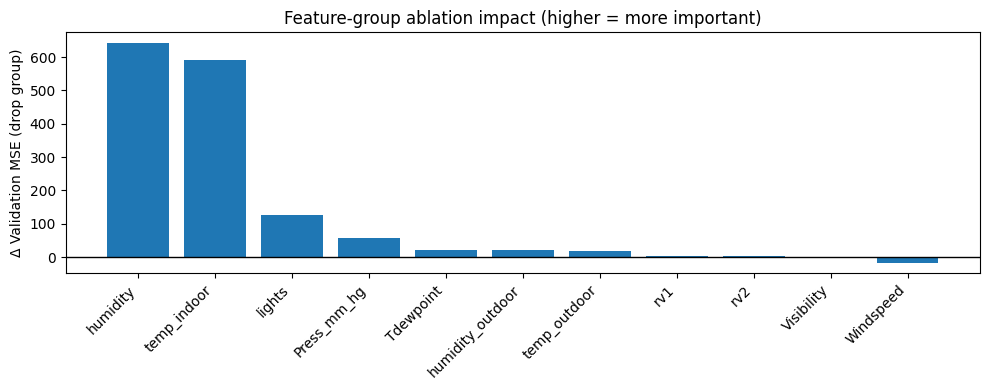

In [13]:
# 2) Feature-group ablation using the best-performing basis config above
# ------------------------

best_basis_name = basis_ablation_results[0]['model']
best_cfg = basis_configs[best_basis_name]
print(f"\nUsing best basis for feature ablation: {best_basis_name}")

feature_groups = select_feature_groups(feature_names)

# Full model baseline
Phi_tr_full = make_design_matrix(X_train_s, basis=best_cfg, add_linear=True)
Phi_va_full = make_design_matrix(X_val_s, basis=best_cfg, add_linear=True)
w_full = fit_ridge(Phi_tr_full, y_train, lam=lam)
base_val = mse(y_val, Phi_va_full @ w_full)

feat_ablation = []
for gname, cols in feature_groups.items():
    keep = np.ones(X_train_s.shape[1], dtype=bool)
    keep[cols] = False  # drop this group

    Xtr = X_train_s[:, keep]
    Xva = X_val_s[:, keep]
    Xte = X_test_s[:, keep]

    # Need to adapt basis params to reduced dimensionality.
    # For Poly: OK. For RBF/Sigmoid/Spline: recompute params from reduced Xtr to avoid dimension mismatch / leakage.

    # Shallow-copy top-level and 1-level nested dicts so we can mutate safely per iteration
    cfg = {
        k: (dict(v) if isinstance(v, dict) else v)
        for k, v in best_cfg.items()
    }

    # Recompute RBF centers if used
    if cfg.get('rbf') is not None:
        K = cfg['rbf']['centers'].shape[0]
        rng = np.random.default_rng(0)
        idx_c = rng.choice(Xtr.shape[0], size=min(K, Xtr.shape[0]), replace=False)
        centers = Xtr[idx_c]
        if centers.shape[0] >= 2:
            sample = centers[rng.choice(centers.shape[0], size=min(200, centers.shape[0]), replace=False)]
            d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
            med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
        else:
            med = 1.0
        gamma = 1.0 / (2.0 * med)
        cfg['rbf'] = {'centers': centers, 'gamma': gamma}

    # Recompute sigmoid centers if used
    if cfg.get('sigmoid') is not None:
        M = cfg['sigmoid']['centers'].shape[1]
        qs = np.linspace(0.1, 0.9, M)
        D2 = Xtr.shape[1]
        centers_pf = np.zeros((D2, M), dtype=float)
        for d in range(D2):
            centers_pf[d] = np.quantile(Xtr[:, d], qs)
        cfg['sigmoid'] = {'centers': centers_pf, 'slope': float(cfg['sigmoid']['slope'])}

    # Reset spline transformer if used (must refit on reduced Xtr)
    if cfg.get('spline') is not None:
        cfg['spline'] = {
            'n_knots': int(cfg['spline']['n_knots']),
            'degree': int(cfg['spline'].get('degree', 3)),
            # transformer intentionally omitted so make_design_matrix refits on Xtr
        }

    Phi_tr = make_design_matrix(Xtr, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(Xva, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(Xte, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)

    val_m = mse(y_val, Phi_va @ w)
    test_m = mse(y_test, Phi_te @ w)
    feat_ablation.append({
        'dropped_group': gname,
        'delta_val_mse': val_m - base_val,
        'val_mse': val_m,
        'test_mse': test_m,
    })

feat_ablation = sorted(feat_ablation, key=lambda r: r['delta_val_mse'], reverse=True)
print('\nFeature-group ablation (bigger +delta means group is more important):')
for r in feat_ablation:
    print(f"- drop {r['dropped_group']:<16} | Δval MSE={r['delta_val_mse']:+.4f} | val={r['val_mse']:.4f} | test={r['test_mse']:.4f}")

plt.figure(figsize=(10, 4))
plt.bar([r['dropped_group'] for r in feat_ablation], [r['delta_val_mse'] for r in feat_ablation])
plt.axhline(0, color='k', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Δ Validation MSE (drop group)')
plt.title('Feature-group ablation impact (higher = more important)')
plt.tight_layout()
plt.show()


# ------------------------


## **6. Interaction Effects Analysis**
### **6.1 Pairwise Product Terms (xi * xj)**


In [14]:
# Interaction analysis: add x_i x_j and measure improvement
# Strategy: choose top-k features by |corr(x, y)| on train, then add pairwise products.
# ------------------------

# compute correlation on train (scaled X)
yc = y_train - y_train.mean()
Xc = X_train_s - X_train_s.mean(axis=0)
# corr(x_j, y) = cov / (stdx * stdy)
stdy = yc.std() if yc.std() > 0 else 1.0
stdx = Xc.std(axis=0)
stdx = np.where(stdx == 0, 1.0, stdx)
corr = (Xc.T @ yc) / (len(y_train) * stdx * stdy)

k = 10
topk = np.argsort(np.abs(corr))[-k:][::-1].tolist()
inter_tr = interaction_terms(X_train_s, topk)
inter_va = interaction_terms(X_val_s, topk)
inter_te = interaction_terms(X_test_s, topk)

Phi_tr_no = make_design_matrix(X_train_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_va_no = make_design_matrix(X_val_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_te_no = make_design_matrix(X_test_s, basis=best_cfg, interactions=None, add_linear=True)

Phi_tr_int = make_design_matrix(X_train_s, basis=best_cfg, interactions=inter_tr, add_linear=True)
Phi_va_int = make_design_matrix(X_val_s, basis=best_cfg, interactions=inter_va, add_linear=True)
Phi_te_int = make_design_matrix(X_test_s, basis=best_cfg, interactions=inter_te, add_linear=True)

w_no = fit_ridge(Phi_tr_no, y_train, lam=lam)
w_int = fit_ridge(Phi_tr_int, y_train, lam=lam)

val_no = mse(y_val, Phi_va_no @ w_no)
val_int = mse(y_val, Phi_va_int @ w_int)

test_no = mse(y_test, Phi_te_no @ w_no)
test_int = mse(y_test, Phi_te_int @ w_int)

print('\nInteraction terms analysis:')
print('- Selected top-k features for interactions:')
for j in topk:
    print(f"  * {feature_names[j]} (corr={corr[j]:+.3f})")
print(f"- #interaction terms added: {inter_tr.shape[1]}")
print(f"- Baseline (no interactions): val MSE={val_no:.4f}, test MSE={test_no:.4f}")
print(f"- With interactions (x_i x_j): val MSE={val_int:.4f}, test MSE={test_int:.4f}")
print(f"- Improvement (val): {val_no - val_int:+.4f}")
print(f"- Improvement (test): {test_no - test_int:+.4f}")



Interaction terms analysis:
- Selected top-k features for interactions:
  * lights (corr=+0.226)
  * T2 (corr=+0.150)
  * RH_out (corr=-0.147)
  * T3 (corr=+0.121)
  * RH_8 (corr=-0.116)
  * T6 (corr=+0.108)
  * T_out (corr=+0.093)
  * RH_1 (corr=+0.089)
  * T1 (corr=+0.084)
  * RH_6 (corr=-0.084)
- #interaction terms added: 45
- Baseline (no interactions): val MSE=7082.8891, test MSE=10590.5067
- With interactions (x_i x_j): val MSE=7962.7217, test MSE=34535.5491
- Improvement (val): -879.8326
- Improvement (test): -23945.0424
